# DeepSeek-V4-Flash-Vision on 4× CMP 170HX: rerun with all four cards at x16, NCCL P2P level, and PP4 after the fix

| Measured, DSpark k=6, 140 W | TP4, one card x8 (before the fix) | **TP4, all x16, SYS off** | PP4, all x16, SYS off |
|---|---:|---:|---:|
| Known answers / short prompts on topic | 4 / 5, 3 / 5 | **5 / 5, 5 / 5** | 5 / 5, 5 / 5 |
| Prefill, 2,941-token prompt (tok/s) | 1,292 | **2,009** | 2,365 |
| Decode total, 1 / 2 / 4 / 8 users (tok/s) | 168 / 174 / 297 / 258 | **85 / 133 / 228 / 303** | 103 / 90 / 167 / 216 |
| Image requests, 1 / 2 / 4 users (tok/s) | 44 / 69 / 142 | **104 / 124 / 155** | 42 / 92 / crash (Xid 43) |

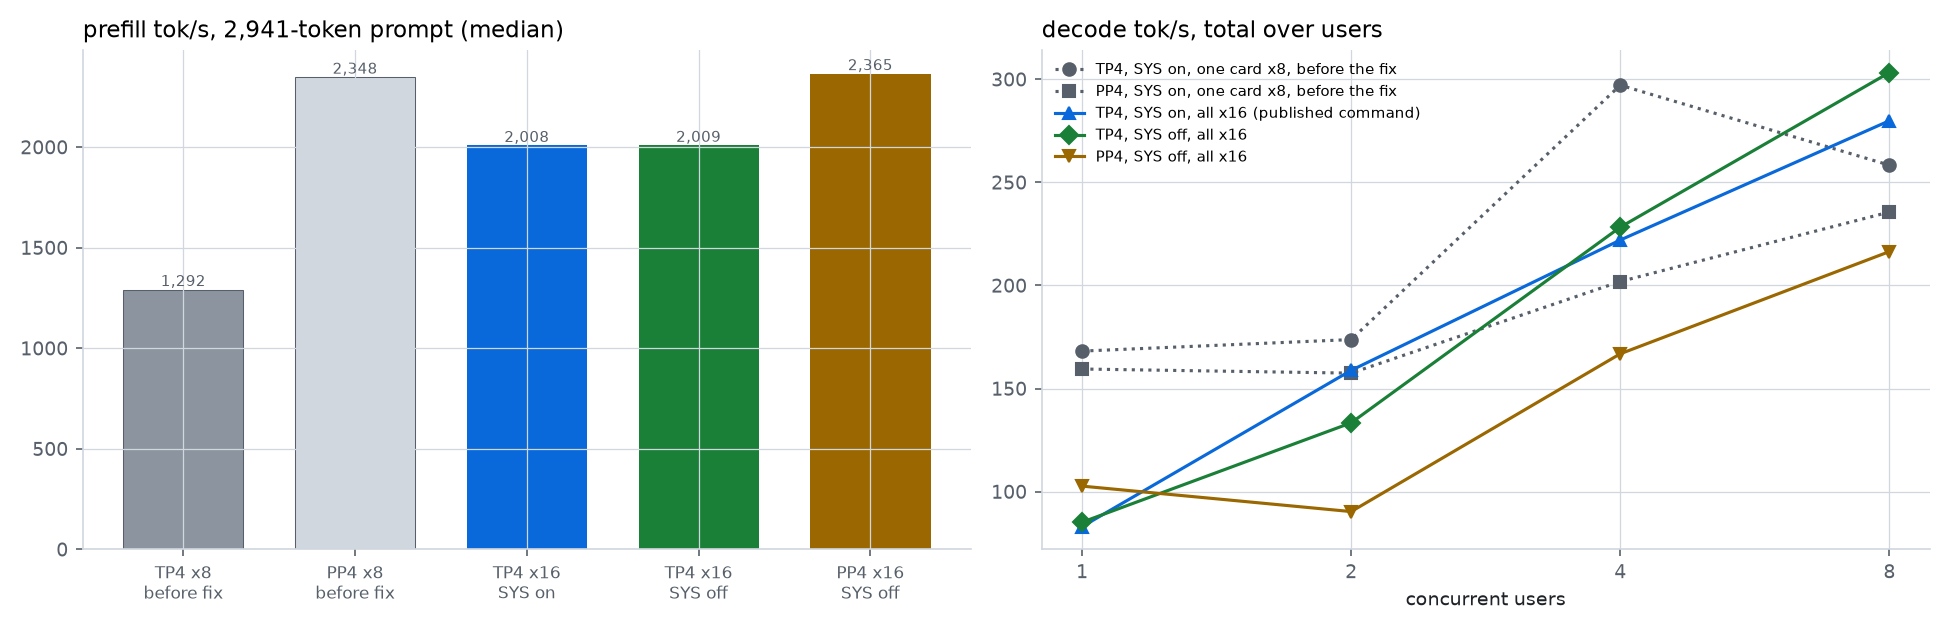

**Verdict (measured):** with all four cards at x16, TP4 prefill rises 55% (1,292 → 2,009 tok/s), and the published fix holds: 5 / 5 known answers and 5 / 5 short prompts on topic in every x16 run. `NCCL_P2P_LEVEL=SYS` no longer changes prefill (2,008 vs 2,009 tok/s); at x8 it cost about 15%. PP4 now prefills only 18% faster than TP4 (it was 1.8×), is slower for 2–8 users, and still crashes at four concurrent image requests (Xid 43). TP4 stays the served layout. The x8 TP4 row ran the image before the fix; its decode numbers include off-topic replies.

```
docker pull ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-04-deepseek-v4-flash-vision-exp-4card-x16-nccl-sys-pp4-vllm"
RECEIPTS = "../results/" + EXPERIMENT + "/receipts"
OLD_RECEIPTS = "../results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/receipts"
LIVE = False  # True sends the final request to the endpoint in DSV4V_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "DSV4V_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-04-deepseek-v4-flash-vision-exp-4card-x16-nccl-sys-pp4-vllm/receipts


In [2]:
# --- Helpers ---
import json, csv, statistics as st
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

def J(d, f):
    return json.load(open(f"{d}/{f}"))
def summary(d):
    c = J(d, "correctness.json"); p = J(d, "probe.json")
    s = {"correct": f"{sum(x['pass'] for x in c['cases'])} / {len(c['cases'])}",
         "on_topic": f"{sum(bool(x.get('on_topic')) for x in p)} / {len(p)}",
         "vision": "yes" if J(d, "vision-check.json").get("keyword_match") else "no",
         "prefill": st.median(r["prefill_tok_s"] for r in J(d, "prefill.json")["reps"] if r.get("ok")),
         "xid": sum(1 for l in open(f"{d}/dmesg-xid.txt") if l.strip())}
    for f, key in (("ladder.json", "txt"), ("ladder_image.json", "img")):
        for lv in J(d, f)["levels"]:
            reps = lv["reps"]
            s[f"{key}{lv['concurrency']}"] = (st.median(r["aggregate_tok_s"] for r in reps), all(r["failed"] == 0 for r in reps))
    return s
def peak_temp(d):
    t = []
    for r in list(csv.reader(open(f"{d}/telemetry.csv"), skipinitialspace=True))[1:]:
        try: t.append(float(r[2]))
        except (ValueError, IndexError): pass
    return f"{max(t):.0f}" if t else "–"

RUNS = [(OLD_RECEIPTS + "/tp4-p2p", "TP4, SYS on, one card x8, before the fix"),
        (OLD_RECEIPTS + "/pp4-p2p", "PP4, SYS on, one card x8, before the fix"),
        (RECEIPTS + "/x16-tp4-sys", "TP4, SYS on, all x16 (published command)"),
        (RECEIPTS + "/x16-tp4-nosys", "TP4, SYS off, all x16"),
        (RECEIPTS + "/x16-pp4-nosys", "PP4, SYS off, all x16")]
SUM = {lab: summary(d) for d, lab in RUNS}

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#8c959f", "#d0d7de", "#0969da", "#1a7f37", "#9a6700"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})

## 1. TL;DR

- **Measured:** TP4 prefill is 2,008–2,009 tok/s with all four cards at x16 (1,292 with one card at x8; the published runs after the fix measured 1,283–1,321 at x8).
- **Measured:** at x16, `NCCL_P2P_LEVEL=SYS` and NCCL's own choice give the same prefill. The 15% cost of SYS at x8 came from the narrow link.
- **Measured:** every x16 run answers 5 / 5 known answers and keeps 5 / 5 short prompts on topic, and the image question passes. The CUDA-graph fix holds at x16.
- **Measured:** PP4 prefill barely changes with the link (2,348 → 2,365 tok/s): pipeline stages send only one activation tensor between cards. TP4 sends all-reduces in every layer, so the wider link helps it most.
- **Measured:** PP4 still fails at four concurrent image requests (Xid 43 on one card, ladder stopped), as it did before the fix. TP4 runs every level without errors.
- **Measured:** one-user decode is 83–103 tok/s in the x16 runs. The published runs after the fix measured 82 and 132 tok/s at x8, so decode did not change measurably with the link. **Inferred:** the x8 rows in this notebook ran before the fix, when DeepSeek-V4 attention ran inside captured CUDA graphs (faster, sometimes wrong); their decode is not comparable. One boot per row is not enough to rank decode between the x16 rows.

In [3]:
pins = {
    "served image (with the fixes)": "ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba (unchanged from the 2026-10-04 autoresearch notebook)",
    "build recipe and patches": "results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/build",
    "model": "deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9",
    "drafter": "DSpark from the checkpoint's MTP layers, num_speculative_tokens 6",
    "serve arguments": "the published command (section 4): --disable-custom-all-reduce, FULL_DECODE_ONLY CUDA graphs, fp8 KV, block 256, 16,384 context, 8 sequences, 2,048 batched tokens",
    "arms": "SYS on = -e NCCL_P2P_LEVEL=SYS (published); SYS off = no NCCL_P2P_LEVEL; PP4 = --pipeline-parallel-size 4 -e VLLM_PP_LAYER_PARTITION=11,11,11,10",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; privileged LXC sharing the host driver (GPUs by CDI)",
    "topology": "two PLX switches, PCIe Gen2; all four cards x16 here (nvidia-smi-loaded.csv per run); the x8 rows are the 2026-10-04 autoresearch receipts",
    "power / HBM": "nvidia-smi -pl 140; HBM 1,728 MHz on all cards (170tune NDIV 64)",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| served image (with the fixes) | ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba (unchanged from the 2026-10-04 autoresearch notebook) |
| build recipe and patches | results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/build |
| model | deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9 |
| drafter | DSpark from the checkpoint's MTP layers, num_speculative_tokens 6 |
| serve arguments | the published command (section 4): --disable-custom-all-reduce, FULL_DECODE_ONLY CUDA graphs, fp8 KV, block 256, 16,384 context, 8 sequences, 2,048 batched tokens |
| arms | SYS on = -e NCCL_P2P_LEVEL=SYS (published); SYS off = no NCCL_P2P_LEVEL; PP4 = --pipeline-parallel-size 4 -e VLLM_PP_LAYER_PARTITION=11,11,11,10 |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; privileged LXC sharing the host driver (GPUs by CDI) |
| topology | two PLX switches, PCIe Gen2; all four cards x16 here (nvidia-smi-loaded.csv per run); the x8 rows are the 2026-10-04 autoresearch receipts |
| power / HBM | nvidia-smi -pl 140; HBM 1,728 MHz on all cards (170tune NDIV 64) |

## 2. Results (measured)

`protocol.sh` from the 2026-10-04 autoresearch notebook, unchanged: greedy known answers (5), short-prompt probes (5, the bug the fix removed), one image question, uncached prefill of a 2,941-token prompt (median), and concurrency ladders (400 tokens, temperature 0, median aggregate of 3 runs per level). One boot per row. The x8 rows ran the image before the fix (`ghcr.io/pixelml/club-170hx@sha256:b26232f8f041c988d3285e2278c9f5001cc49f96131bb0b22a9d38b5e5e061cd`), so their quality columns show the bug. ✗ = at least one request of that level failed.

In [4]:
rows = []
for d, lab in RUNS:
    s = SUM[lab]
    rows.append([lab, s["correct"], s["on_topic"], s["vision"], f"{s['prefill']:,.0f}"]
                + [f"{s[f'txt{c}'][0]:.1f}" + ("" if s[f"txt{c}"][1] else " ✗") for c in (1, 2, 4, 8)]
                + [" / ".join(f"{s[f'img{c}'][0]:.1f}" + ("" if s[f"img{c}"][1] else " ✗") for c in (1, 2, 4)), s["xid"], peak_temp(d)])
table(["configuration", "known answers", "short prompts on topic", "image", "prefill tok/s", "1 user", "2 users", "4 users", "8 users",
       "image 1 / 2 / 4 users", "Xid lines", "peak °C"], rows)

| configuration | known answers | short prompts on topic | image | prefill tok/s | 1 user | 2 users | 4 users | 8 users | image 1 / 2 / 4 users | Xid lines | peak °C |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| TP4, SYS on, one card x8, before the fix | 4 / 5 | 3 / 5 | yes | 1,292 | 168.2 | 173.8 | 297.1 | 258.4 | 43.7 / 68.8 / 141.9 | 0 | 72 |
| PP4, SYS on, one card x8, before the fix | 4 / 5 | 3 / 5 | yes | 2,348 | 159.5 | 157.5 | 201.9 | 235.6 | 46.3 / 87.4 / 122.3 | 6 | 72 |
| TP4, SYS on, all x16 (published command) | 5 / 5 | 5 / 5 | yes | 2,008 | 83.0 | 158.8 | 222.0 | 279.9 | 66.2 / 117.8 / 152.5 | 0 | 71 |
| TP4, SYS off, all x16 | 5 / 5 | 5 / 5 | yes | 2,009 | 85.2 | 133.4 | 228.3 | 303.3 | 104.2 / 123.7 / 155.4 | 0 | 72 |
| PP4, SYS off, all x16 | 5 / 5 | 5 / 5 | yes | 2,365 | 102.7 | 90.3 | 166.9 | 216.4 | 42.2 / 91.9 / 38.6 ✗ | 1 | 70 |

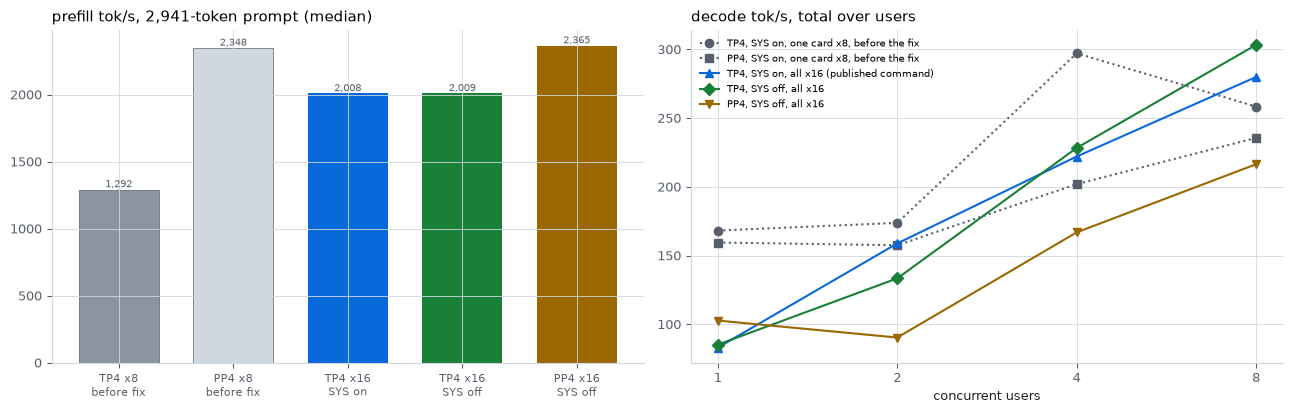

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
labs = [lab for _, lab in RUNS]
for i, lab in enumerate(labs):
    s = SUM[lab]
    axes[0].bar(i, s["prefill"], 0.7, color=S[i], edgecolor=INK2 if i < 2 else "none", linewidth=0.5)
    axes[0].text(i, s["prefill"], f"{s['prefill']:,.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
    axes[1].plot([1, 2, 4, 8], [s[f"txt{c}"][0] for c in (1, 2, 4, 8)], marker="os^Dv"[i], color=S[i] if i > 1 else INK2,
                 ls="-" if i > 1 else ":", label=lab)
axes[0].set_xticks(range(len(labs)), ["TP4 x8\nbefore fix", "PP4 x8\nbefore fix", "TP4 x16\nSYS on", "TP4 x16\nSYS off", "PP4 x16\nSYS off"], fontsize=8)
axes[0].set_title("prefill tok/s, 2,941-token prompt (median)", loc="left")
axes[1].set_xscale("log", base=2); axes[1].set_xticks([1, 2, 4, 8], ["1", "2", "4", "8"])
axes[1].set_title("decode tok/s, total over users", loc="left"); axes[1].set_xlabel("concurrent users")
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()
for ext in ("png", "svg"):
    fig.savefig(f"../assets/charts/2026-10-04-deepseek-v4-flash-vision-exp-4card-x16-nccl-sys-pp4-vllm.{ext}", dpi=150)
plt.show()

- **Measured:** the x16 link helps TP4 prefill by 55%, more than GLM-5.3-Flash on the same host (+44%). Why the gain is larger here is not measured.
- **Measured:** SYS on vs off at x16: prefill equal; decode differs by −16% to +8% between levels, in both directions. We read that as run-to-run spread, not as an effect of the setting.
- **Measured:** PP4 at x16: 2,365 tok/s prefill (+18% over TP4), but lower decode at 2–8 users and a crash at four image users. Use TP4.
- **Recommended:** keep the published command. `NCCL_P2P_LEVEL=SYS` can stay or go on a host with all links at x16; on a host with an x8 link, drop it.

## 3. What this does not show (untested)

- Run-to-run spread: one boot per row. The autoresearch notebook measured ±40% on one-user decode between runs of the same configuration.
- Power above 140 W, custom all-reduce at x16 (the published command turns it off), PP4 with SYS on at x16.

## 4. Reproduce

The served command is in the [autoresearch notebook](2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm.ipynb), section 7, with `ghcr.io/pixelml/club-170hx@sha256:97ecb29396abc87a9a4f99e18e561f97dc610ca1d79788819d374f5fff1205ba`. For the SYS-off rows drop `-e NCCL_P2P_LEVEL=SYS`. For PP4 replace `--tensor-parallel-size 4` with `--pipeline-parallel-size 4` and add `-e VLLM_PP_LAYER_PARTITION=11,11,11,10`. The loop that ran the three arms: `results/2026-10-04-deepseek-v4-flash-vision-exp-4card-x16-nccl-sys-pp4-vllm/chain.sh`; the bench: `results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/build/protocol.sh` with the scripts in `results/2026-10-04-deepseek-v4-flash-vision-exp-4card-tp4-autoresearch-vllm/autoresearch/`.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints the recorded short-prompt probes of the served configuration (the prompts that went off topic before the fix).

In [6]:
PROMPT = "Write a Python function that checks if a number is prime."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "dsv4v", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 300, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"].get("content")); print(resp["usage"])
else:
    for x in J(RECEIPTS + "/x16-tp4-nosys", "probe.json"):
        print(x["name"], "on topic:", x.get("on_topic"), "|", x["content"][:90].replace("\n", " "))

prime-bare on topic: True | Here's a Python function that checks if a number is prime:  ```python def is_prime(n):    
prime-think on topic: True | We need to write a Python function that checks if a number is prime. The user didn't speci
prime-system on topic: True | Here's a Python function that checks if a number is prime:  ```python def is_prime(n):    
is_prime-97 on topic: True | Here's the Python function:  ```python def is_prime(n):     if n < 2:         return False
sky on topic: True | The sky appears blue because sunlight is made of all colors, and air molecules scatter blu
